# Notebook 02 — EDA & Preprocessing

**Mục đích:** Thực hiện EDA chi tiết và toàn bộ bước tiền xử lý trên Wine Dataset.

**Dữ liệu đầu vào:** Ba file `data/processed/train_raw.csv`, `val_raw.csv`, `test_raw.csv` đã được split ở notebook 01 — vẫn còn nguyên missing/duplicate/outlier.

**Thứ tự trình bày** (theo yêu cầu báo cáo):
1. EDA tổng quan
2. Phân phối dữ liệu
3. Correlation Matrix
4. Feature Engineering (xử lý missing, duplicate, outlier)
5. Encoding
6. Standardization
7. Xuất báo cáo tóm tắt

> **Anti-Leakage:** Tham số clean (median, IQR) và scaler (mean, std) đều chỉ được **fit từ Train**. Val và Test chỉ được transform.

## 0. Setup

In [2]:
import sys
import pathlib
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.preprocessing import (
    fit_clean_params, clean,
    encode_if_needed,
    fit_scaler, scale,
    save_pipeline_params,
    WINE_NUMERICAL_COLS, WINE_TARGET_COL,
)

# --- Đường dẫn (tuyệt đối, dựa trên PROJECT_ROOT) ---
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

numerical_cols = WINE_NUMERICAL_COLS
target_col     = WINE_TARGET_COL

# Style chung cho matplotlib
plt.rcParams.update({
    'figure.dpi'     : 110,
    'axes.titlesize' : 9,
    'axes.labelsize' : 8,
})
sns.set_theme(style='white')

# ── Bảng màu & style dùng thống nhất cho toàn bộ notebook (chuẩn slide) ──
PALETTE = {
    "ink":     "#1D2A35",   # màu chữ / trục chính
    "grid":    "#E4E7EB",   # màu lưới nhạt
    "before":  "#E15554",   # đỏ san hô — dữ liệu TRƯỚC xử lý / vấn đề
    "after":   "#2A9D8F",   # xanh ngọc — dữ liệu SAU xử lý / đã sạch
    "accent":  "#3D5A80",   # xanh navy — nhấn mạnh trung tính
    "neutral": "#98A6B3",   # xám xanh — nền/không nổi bật
}
# Bảng màu cho 3 lớp Customer_Segment — dùng xuyên suốt kể cả bên PCA (Đăng)
CLASS_PALETTE = {1: "#3D5A80", 2: "#E9A845", 3: "#2A9D8F"}

plt.rcParams.update({
    'figure.dpi'        : 130,
    'savefig.dpi'        : 220,
    'savefig.facecolor'  : 'white',
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : PALETTE["ink"],
    'axes.linewidth'     : 0.8,
    'axes.titlesize'     : 12,
    'axes.titleweight'   : 'bold',
    'axes.titlepad'      : 10,
    'axes.labelsize'     : 9.5,
    'axes.labelcolor'    : PALETTE["ink"],
    'axes.grid'          : True,
    'axes.axisbelow'     : True,
    'grid.color'         : PALETTE["grid"],
    'grid.linewidth'     : 0.7,
    'grid.linestyle'     : '-',
    'xtick.color'        : PALETTE["ink"],
    'ytick.color'        : PALETTE["ink"],
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'legend.frameon'     : False,
    'font.family'        : 'DejaVu Sans',
    'text.color'         : PALETTE["ink"],
})

def style_axes(ax):
    """Bỏ khung trên/phải, giữ lưới ngang nhẹ — phong cách slide gọn gàng."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(PALETTE["ink"])
    ax.spines['bottom'].set_color(PALETTE["ink"])
    ax.grid(axis='y', alpha=0.6)

def fig_title(fig, title, subtitle=None, y=0.98, title_size=15, subtitle_size=9.5):
    fig_h = fig.get_figheight()
    fig.text(0.5, y, title, ha='center', va='top', fontsize=title_size,
              fontweight='bold', color=PALETTE["ink"])
    if subtitle:
        gap_inch = (title_size * 1.5) / 72.0   # khoảng cách ~1.5x cỡ chữ title, quy ra inch
        fig.text(0.5, y - gap_inch / fig_h, subtitle, ha='center', va='top',
                  fontsize=subtitle_size, color=PALETTE["neutral"], style='italic')

print('Setup OK  |  numerical_cols:', numerical_cols)
print('Bang mau CLASS_PALETTE:', CLASS_PALETTE)

Setup OK  |  numerical_cols: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']
Bang mau CLASS_PALETTE: {1: '#3D5A80', 2: '#E9A845', 3: '#2A9D8F'}


In [3]:
# --- Đọc 3 tập raw (đã split, chưa clean) ---
train_df = pd.read_csv(PROCESSED_DIR / 'train_raw.csv')
val_df   = pd.read_csv(PROCESSED_DIR / 'val_raw.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test_raw.csv')

print('Shapes raw:')
print(f'  Train : {train_df.shape}')
print(f'  Val   : {val_df.shape}')
print(f'  Test  : {test_df.shape}')

Shapes raw:
  Train : (127, 14)
  Val   : (27, 14)
  Test  : (27, 14)


---
## Section 1: EDA Tổng Quan Trên Train

Khám phá cấu trúc, kiểu dữ liệu và các vấn đề chất lượng dữ liệu của tập Train raw.

> Toàn bộ EDA ở Section 1–3 chỉ thực hiện trên **tập Train** để tránh data leakage. Val và Test không được quan sát trước khi split.

### 1.1 Thông tin cơ bản — `info()` và `describe()`

In [4]:
print('=== train_df.info() ===')
train_df.info()
print()

=== train_df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               127 non-null    float64
 1   Malic_Acid            127 non-null    float64
 2   Ash                   125 non-null    float64
 3   Ash_Alcanity          127 non-null    float64
 4   Magnesium             127 non-null    float64
 5   Total_Phenols         127 non-null    float64
 6   Flavanoids            127 non-null    float64
 7   Nonflavanoid_Phenols  127 non-null    float64
 8   Proanthocyanins       127 non-null    float64
 9   Color_Intensity       127 non-null    float64
 10  Hue                   125 non-null    float64
 11  OD280                 127 non-null    float64
 12  Proline               127 non-null    float64
 13  Customer_Segment      127 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 14.0 KB



In [5]:
print('=== train_df.describe() ===')
train_df.describe().round(3)

=== train_df.describe() ===


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
count,127.000,127.000,125.000,127.000,127.000,127.000,127.000,127.000,127.000,127.000,125.000,127.000,127.000,127.000
mean,13.030,2.323,2.364,19.466,105.281,2.271,2.018,0.362,1.569,5.052,0.962,2.627,774.387,1.945
std,0.825,1.110,0.267,3.329,58.066,0.618,0.997,0.122,0.584,2.343,0.228,0.695,492.012,0.780
min,11.030,0.740,1.700,11.200,78.000,0.980,0.340,0.140,0.410,1.280,0.480,1.290,278.000,1.000
25%,12.420,1.605,2.200,17.050,88.000,1.700,1.235,0.270,1.150,3.250,0.790,2.055,497.500,1.000
50%,13.070,1.870,2.360,19.500,98.000,2.220,2.040,0.340,1.540,4.800,0.960,2.780,660.000,2.000
75%,13.700,2.975,2.530,21.500,109.000,2.775,2.790,0.430,1.885,6.115,1.120,3.170,1017.500,3.000
max,14.830,5.800,3.230,30.000,732.624,3.880,5.080,0.660,3.580,13.000,1.710,4.000,5011.205,3.000


### 1.2 Kiểm tra kiểu dữ liệu — Numerical vs Categorical

In [6]:
dtype_df = pd.DataFrame({
    'dtype'       : train_df.dtypes,
    'is_numeric'  : train_df.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d)),
})
print(dtype_df)
print()
n_num = int(dtype_df['is_numeric'].sum())
n_cat = len(dtype_df) - n_num
print(f'Cot numerical : {n_num}')
print(f'Cot categorical: {n_cat}')
print()
if n_cat == 0:
    print('Tat ca 13 feature deu la numerical -> khong can encoding cho Wine dataset.')
else:
    cats = dtype_df[~dtype_df['is_numeric']].index.tolist()
    print(f'Cac cot categorical: {cats}')

                        dtype  is_numeric
Alcohol               float64        True
Malic_Acid            float64        True
Ash                   float64        True
Ash_Alcanity          float64        True
Magnesium             float64        True
Total_Phenols         float64        True
Flavanoids            float64        True
Nonflavanoid_Phenols  float64        True
Proanthocyanins       float64        True
Color_Intensity       float64        True
Hue                   float64        True
OD280                 float64        True
Proline               float64        True
Customer_Segment        int64        True

Cot numerical : 14
Cot categorical: 0

Tat ca 13 feature deu la numerical -> khong can encoding cho Wine dataset.


### 1.3 Missing Values

Cot co missing values:
     count   pct
Ash      2  1.57
Hue      2  1.57
Tong so o missing: 4


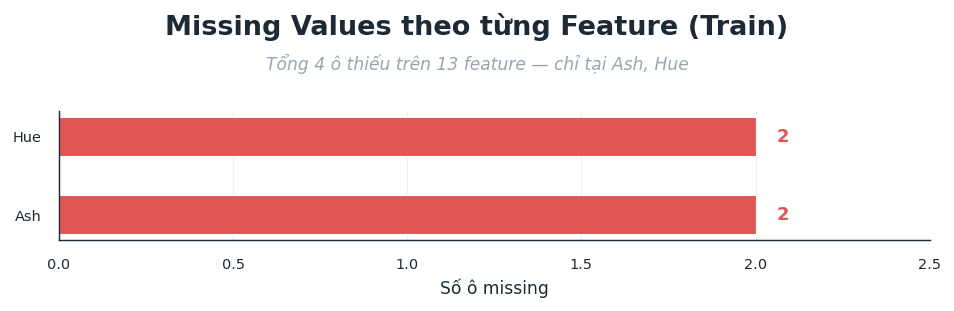

In [7]:
missing = train_df[numerical_cols].isnull().sum()
missing_pct = missing / len(train_df) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct.round(2)})
missing_df = missing_df[missing_df['count'] > 0]

print('Cot co missing values:')
if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print('  (khong co)')
print(f'Tong so o missing: {int(missing.sum())}')

# ── Horizontal bar chart — chỉ hiện các cột CÓ missing, gọn & tập trung ──
missing_all = train_df[numerical_cols].isnull().sum().sort_values(ascending=True)
missing_nonzero = missing_all[missing_all > 0]
plot_data = missing_nonzero if len(missing_nonzero) > 0 else missing_all

fig, ax = plt.subplots(figsize=(7.5, max(2.4, 0.7 * len(plot_data) + 1.1)))
bars = ax.barh(plot_data.index, plot_data.values, color=PALETTE["before"], height=0.5,
                edgecolor='white', linewidth=0.6)
for bar, v in zip(bars, plot_data.values):
    ax.text(v + plot_data.max() * 0.03, bar.get_y() + bar.get_height() / 2,
             f'{int(v)}', va='center', ha='left', fontsize=10,
             color=PALETTE["before"], fontweight='bold')
ax.set_xlim(0, plot_data.max() * 1.25)
ax.set_xlabel('Số ô missing')
ax.set_ylabel('')
style_axes(ax)
ax.grid(axis='x', alpha=0.6)
ax.grid(axis='y', visible=False)
plt.tight_layout(rect=[0, 0, 1, 0.72])
fig_title(fig, 'Missing Values theo từng Feature (Train)',
          f'Tổng {int(missing.sum())} ô thiếu trên {len(numerical_cols)} feature — '
          f'chỉ tại {", ".join(missing_nonzero.index) if len(missing_nonzero) else "không có cột nào"}',
          y=0.95)
plt.savefig(FIGURES_DIR / 'missing_values_bar.png', bbox_inches='tight')
plt.show()


### 1.4 Duplicate Rows

In [8]:
n_dup = int(train_df.duplicated().sum())
print(f'So dong duplicate trong train_df: {n_dup}')
if n_dup > 0:
    print()
    print('Cac dong bi lap (ban sao):')
    display(train_df[train_df.duplicated(keep='first')])

So dong duplicate trong train_df: 1

Cac dong bi lap (ban sao):


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
94,12.42,1.61,2.19,22.5,108.0,2.0,2.09,0.34,1.61,2.06,1.06,2.96,345.0,2


### 1.5 Phân bố nhãn `Customer_Segment` — kiểm tra trực quan Stratified Split

So sánh tỉ lệ 3 lớp giữa Train / Val / Test để xác nhận bằng mắt kết quả Stratified Split đã thực hiện ở notebook 01.

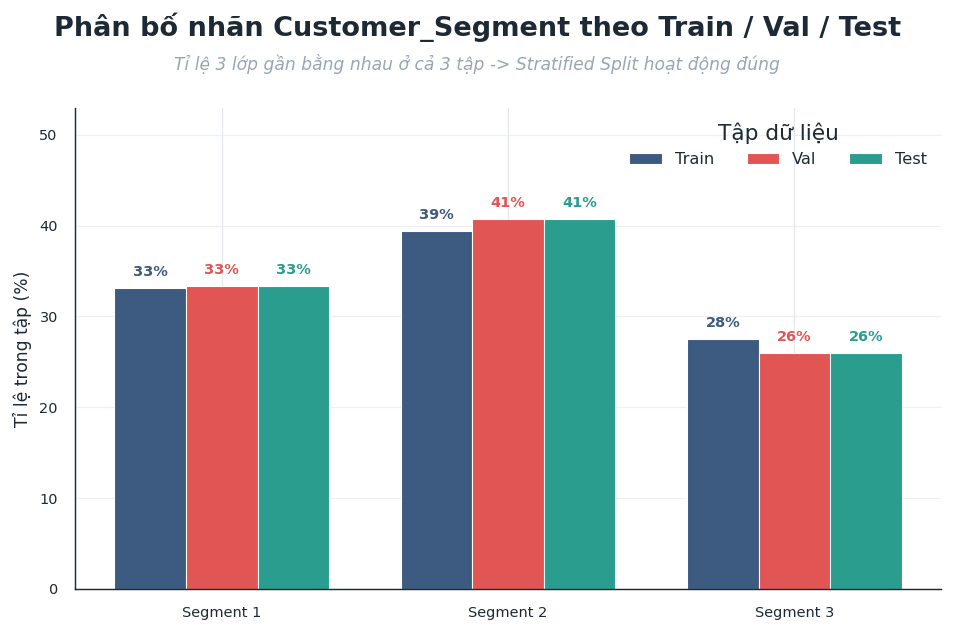

Da luu: reports/figures/class_distribution_split.png


In [9]:
dist_df = pd.DataFrame({
    'Train': train_df[target_col].value_counts(normalize=True).sort_index(),
    'Val':   val_df[target_col].value_counts(normalize=True).sort_index(),
    'Test':  test_df[target_col].value_counts(normalize=True).sort_index(),
}) * 100

x = np.arange(len(dist_df))
width = 0.25
split_colors = {'Train': PALETTE["accent"], 'Val': PALETTE["before"], 'Test': PALETTE["after"]}

fig, ax = plt.subplots(figsize=(7.5, 5))
for i, split_name in enumerate(dist_df.columns):
    bars = ax.bar(x + (i - 1) * width, dist_df[split_name], width,
                   label=split_name, color=split_colors[split_name],
                   edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, dist_df[split_name]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v:.0f}%',
                 ha='center', va='bottom', fontsize=8, color=split_colors[split_name], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Segment {c}' for c in dist_df.index])
ax.set_ylabel('Tỉ lệ trong tập (%)')
ax.set_ylim(0, dist_df.values.max() * 1.3)
style_axes(ax)
ax.legend(title='Tập dữ liệu', loc='upper right', ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.86])
fig_title(fig, 'Phân bố nhãn Customer_Segment theo Train / Val / Test',
          'Tỉ lệ 3 lớp gần bằng nhau ở cả 3 tập -> Stratified Split hoạt động đúng', y=0.97)
plt.savefig(FIGURES_DIR / 'class_distribution_split.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/class_distribution_split.png')

### 1.5 Boxplot Từng Feature (trước khi xử lý outlier)

Dùng boxplot để quan sát outlier bằng mắt. Các điểm nằm ngoài râu (whisker) là outlier theo tiêu chí IQR.

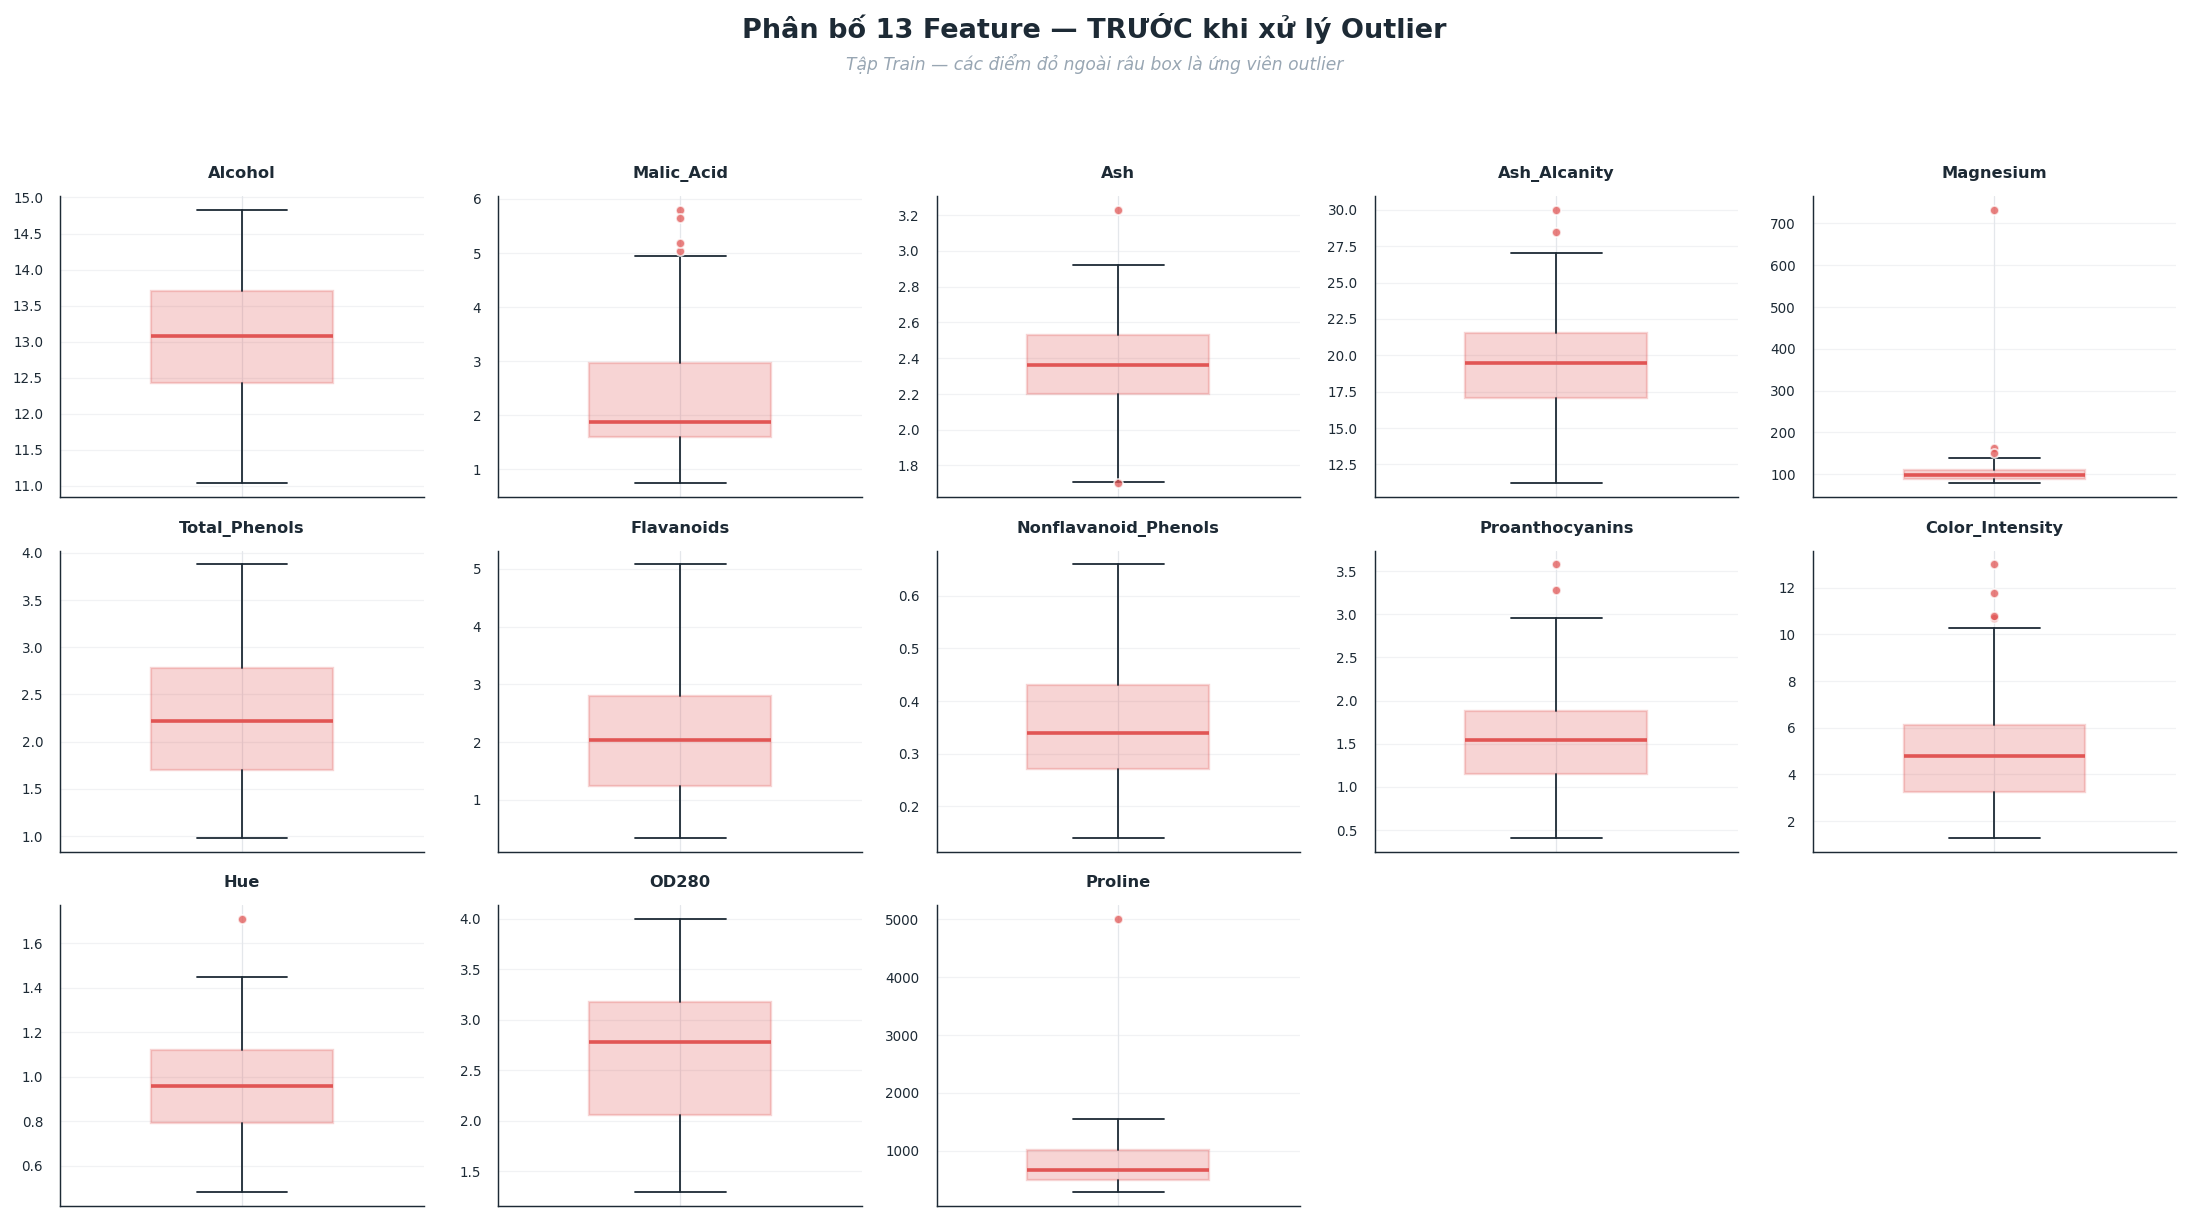

Da luu: reports/figures/boxplot_features_before.png


In [10]:
fig, axes = plt.subplots(3, 5, figsize=(17, 9.5))
axes_flat = axes.flat
for col in numerical_cols:
    ax = next(axes_flat)
    bp = ax.boxplot(train_df[col].dropna(), patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=PALETTE["before"], alpha=0.25, edgecolor=PALETTE["before"], linewidth=1.3),
               medianprops=dict(color=PALETTE["before"], linewidth=2),
               whiskerprops=dict(color=PALETTE["ink"], linewidth=1),
               capprops=dict(color=PALETTE["ink"], linewidth=1),
               flierprops=dict(marker='o', markerfacecolor=PALETTE["before"],
                               markeredgecolor='white', markersize=5, alpha=0.75))
    ax.set_title(col, fontsize=9, fontweight='semibold', color=PALETTE["ink"])
    ax.tick_params(axis='y', labelsize=7.5)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    style_axes(ax)
    ax.grid(axis='y', alpha=0.5)
for ax in axes_flat:
    ax.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
fig_title(fig, 'Phân bố 13 Feature — TRƯỚC khi xử lý Outlier',
          'Tập Train — các điểm đỏ ngoài râu box là ứng viên outlier', y=0.985)
plt.savefig(FIGURES_DIR / 'boxplot_features_before.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/boxplot_features_before.png')


---
## Section 2: Phân Phối Dữ Liệu

Dùng histogram để quan sát phân phối của từng feature, phát hiện các feature bị lệch (skewed) cần lưu ý khi chuẩn hoá.

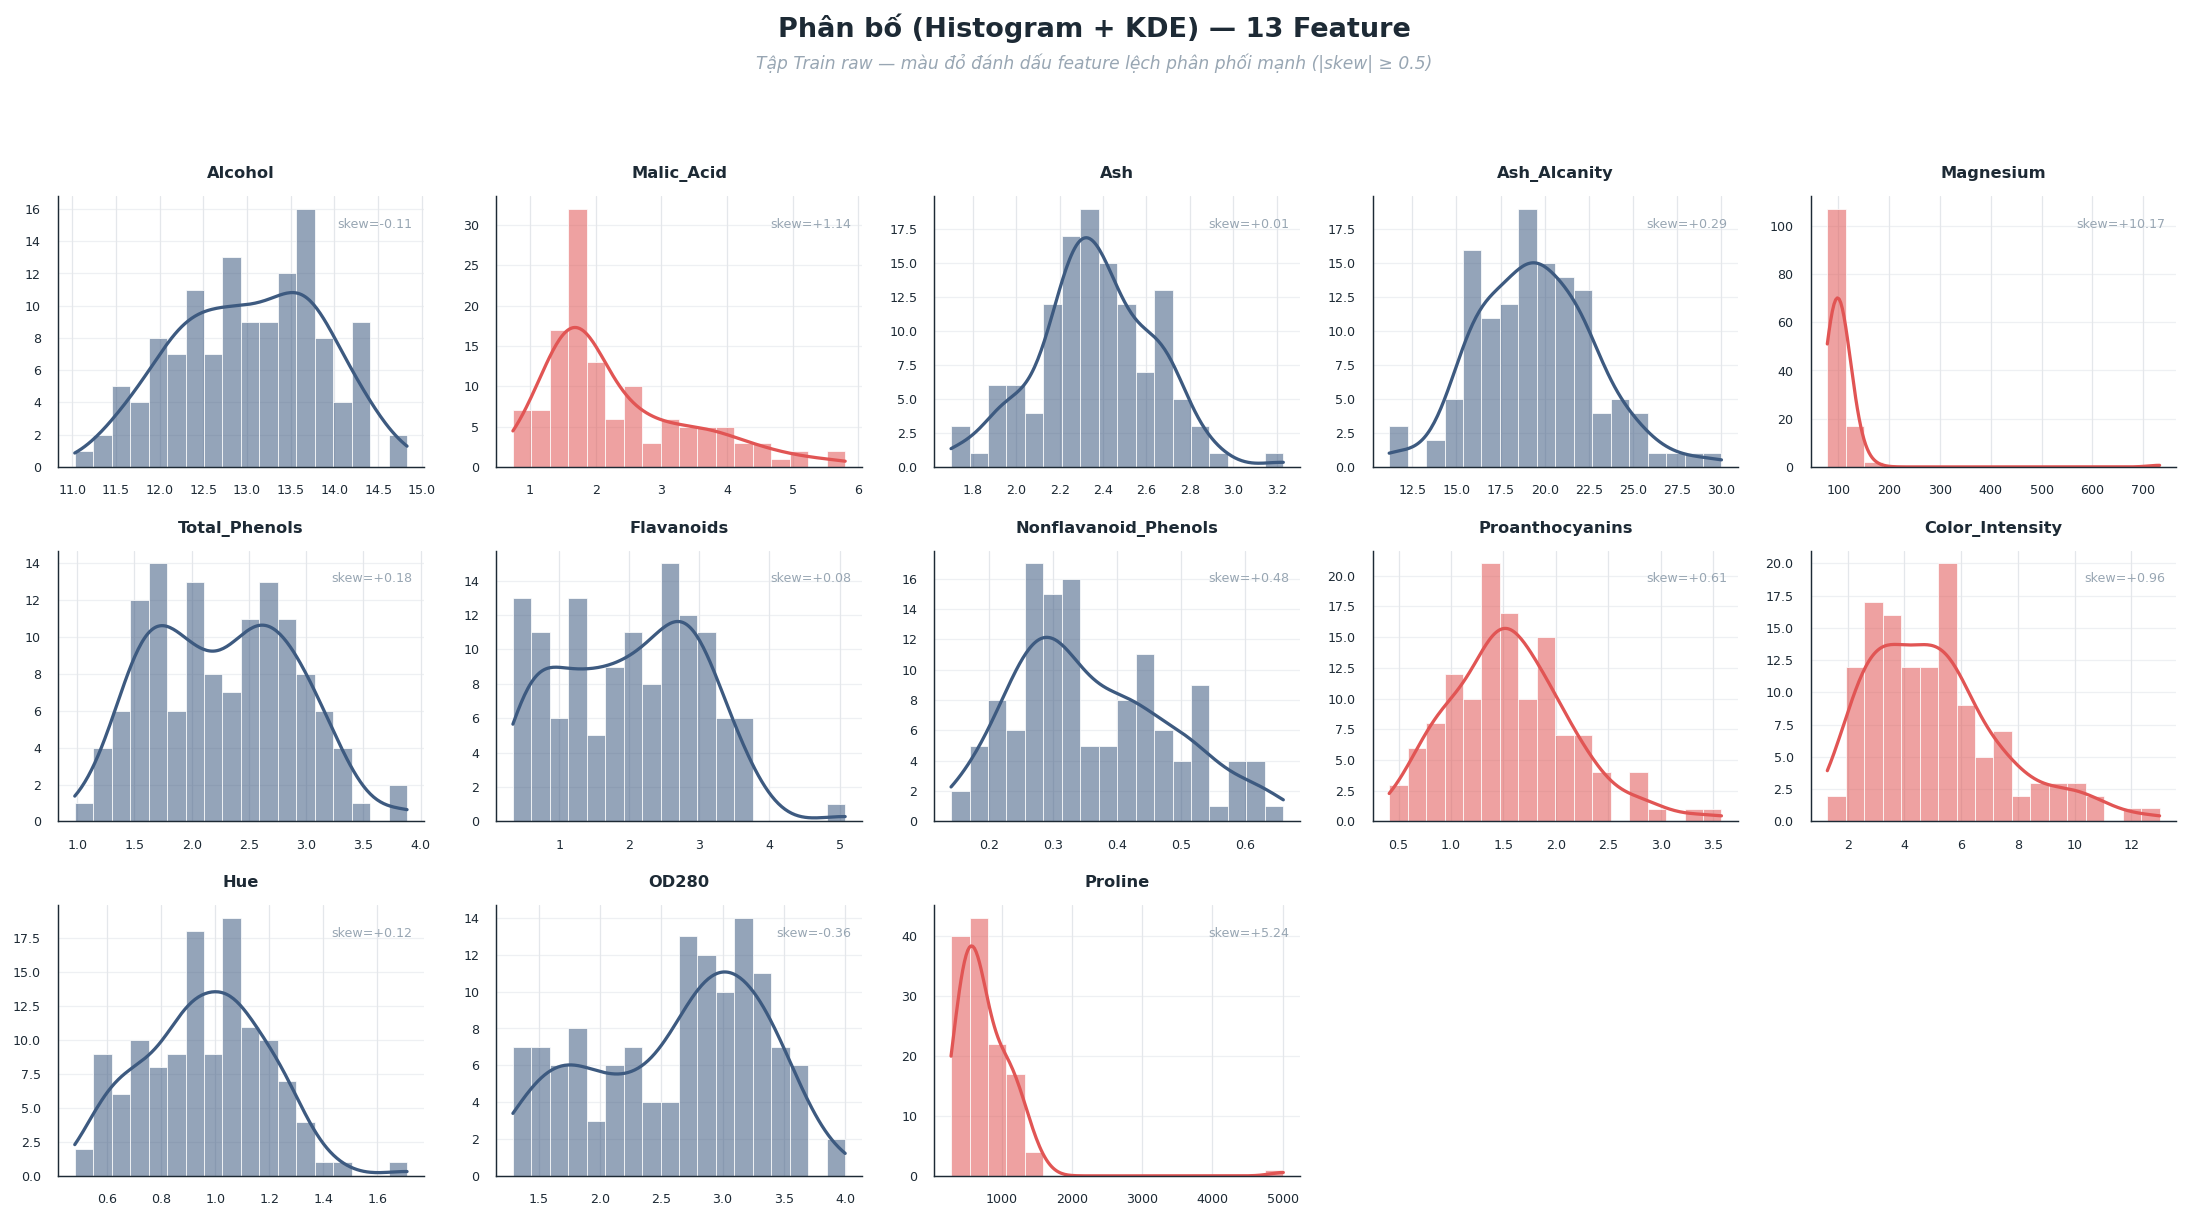

Da luu: reports/figures/histogram_features.png


In [11]:
fig, axes = plt.subplots(3, 5, figsize=(17, 9.5))
axes_flat = axes.flat
for col in numerical_cols:
    ax = next(axes_flat)
    data = train_df[col].dropna()
    skew_val = float(data.skew())
    # Màu theo độ lệch: gần 0 = trung tính, lệch mạnh = nhấn màu accent
    bar_color = PALETTE["accent"] if abs(skew_val) < 0.5 else PALETTE["before"]
    sns.histplot(data, bins=18, kde=True, ax=ax, color=bar_color,
                 edgecolor='white', linewidth=0.4, alpha=0.55,
                 line_kws={'linewidth': 1.8, 'color': PALETTE["ink"]})
    ax.set_title(f'{col}', fontsize=9, fontweight='semibold', color=PALETTE["ink"])
    ax.text(0.97, 0.92, f'skew={skew_val:+.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=7, color=PALETTE["neutral"])
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(labelsize=7)
    style_axes(ax)
for ax in axes_flat:
    ax.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
fig_title(fig, 'Phân bố (Histogram + KDE) — 13 Feature',
          'Tập Train raw — màu đỏ đánh dấu feature lệch phân phối mạnh (|skew| ≥ 0.5)', y=0.985)
plt.savefig(FIGURES_DIR / 'histogram_features.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/histogram_features.png')


### Nhận xét phân phối

| Feature | Skewness ước tính | Nhận xét |
|---------|------------------|-----------|
| **Proline** | > 1.0 | Lệch phải mạnh — phần lớn giá trị thấp, có đuôi dài bên phải |
| **Malic_Acid** | > 0.5 | Lệch phải vừa |
| **Color_Intensity** | > 0.5 | Lệch phải vừa |
| **Alcohol**, **Ash**, **OD280** | ~0 | Gần phân phối chuẩn |
| **Nonflavanoid_Phenols** | ~0 | Gần chuẩn |

> **Kết luận:** Một số feature bị lệch đáng kể. Bước Standardization (z-score) sẽ đưa chúng về cùng thang đo, nhưng không thay đổi hình dạng phân phối. PCA sẽ hoạt động tốt hơn sau khi chuẩn hoá vì các feature không còn bị chi phối bởi đơn vị đo lường.

### Violin Plot — Phân phối Feature theo từng lớp (Customer_Segment)

Histogram ở trên cho phân phối tổng thể; violin plot dưới đây tách theo lớp để xem feature nào phân tách 3 giống nho tốt nhất — hữu ích khi đánh giá sau này PCA có giữ được cấu trúc lớp hay không.

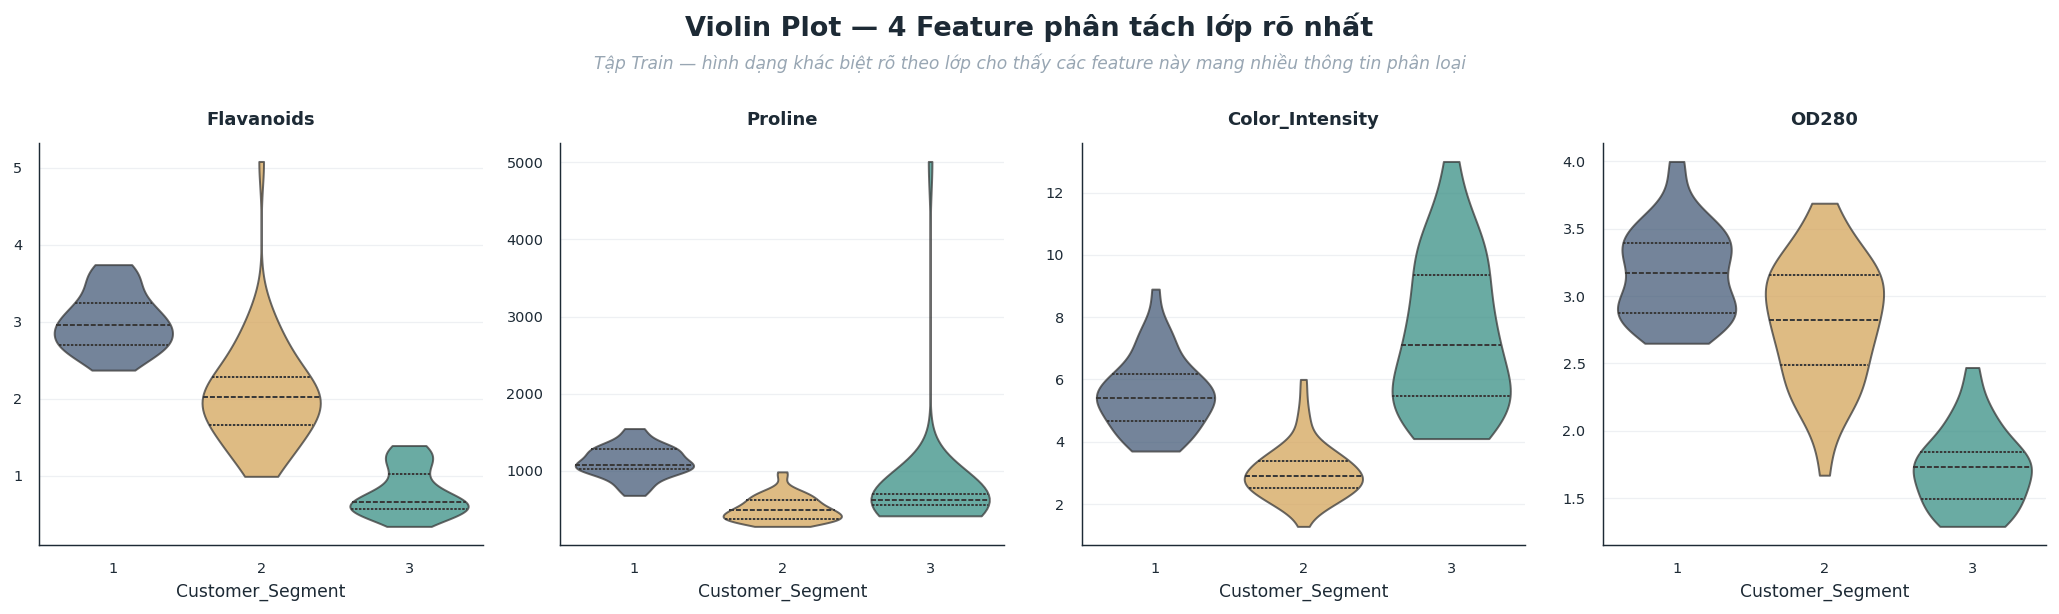

Da luu: reports/figures/violin_by_class.png


In [12]:
VIOLIN_COLS = ['Flavanoids', 'Proline', 'Color_Intensity', 'OD280']

plot_df = train_df.copy()
plot_df[target_col] = plot_df[target_col].astype(str)
class_order = ['1', '2', '3']

fig, axes = plt.subplots(1, len(VIOLIN_COLS), figsize=(16, 4.8))
for ax, col in zip(axes, VIOLIN_COLS):
    sns.violinplot(data=plot_df, x=target_col, y=col, ax=ax, order=class_order,
                    palette={str(k): v for k, v in CLASS_PALETTE.items()},
                    inner='quartile', linewidth=1.1, cut=0)
    for pc in ax.collections:
        pc.set_alpha(0.75)
    ax.set_title(col, fontsize=10, fontweight='semibold', color=PALETTE["ink"])
    ax.set_xlabel('Customer_Segment')
    ax.set_ylabel('')
    style_axes(ax)

plt.tight_layout(rect=[0, 0, 1, 0.86])
fig_title(fig, 'Violin Plot — 4 Feature phân tách lớp rõ nhất',
          'Tập Train — hình dạng khác biệt rõ theo lớp cho thấy các feature này mang nhiều thông tin phân loại', y=0.98)
plt.savefig(FIGURES_DIR / 'violin_by_class.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/violin_by_class.png')

---
## Section 3: Correlation Matrix

Ma trận tương quan (Pearson) giúp xác định các feature có tương quan tuyến tính mạnh với nhau — đây chính là tín hiệu cho thấy PCA có thể nén nhiều chiều thành ít thành phần mà vẫn giữ được phần lớn phương sai.

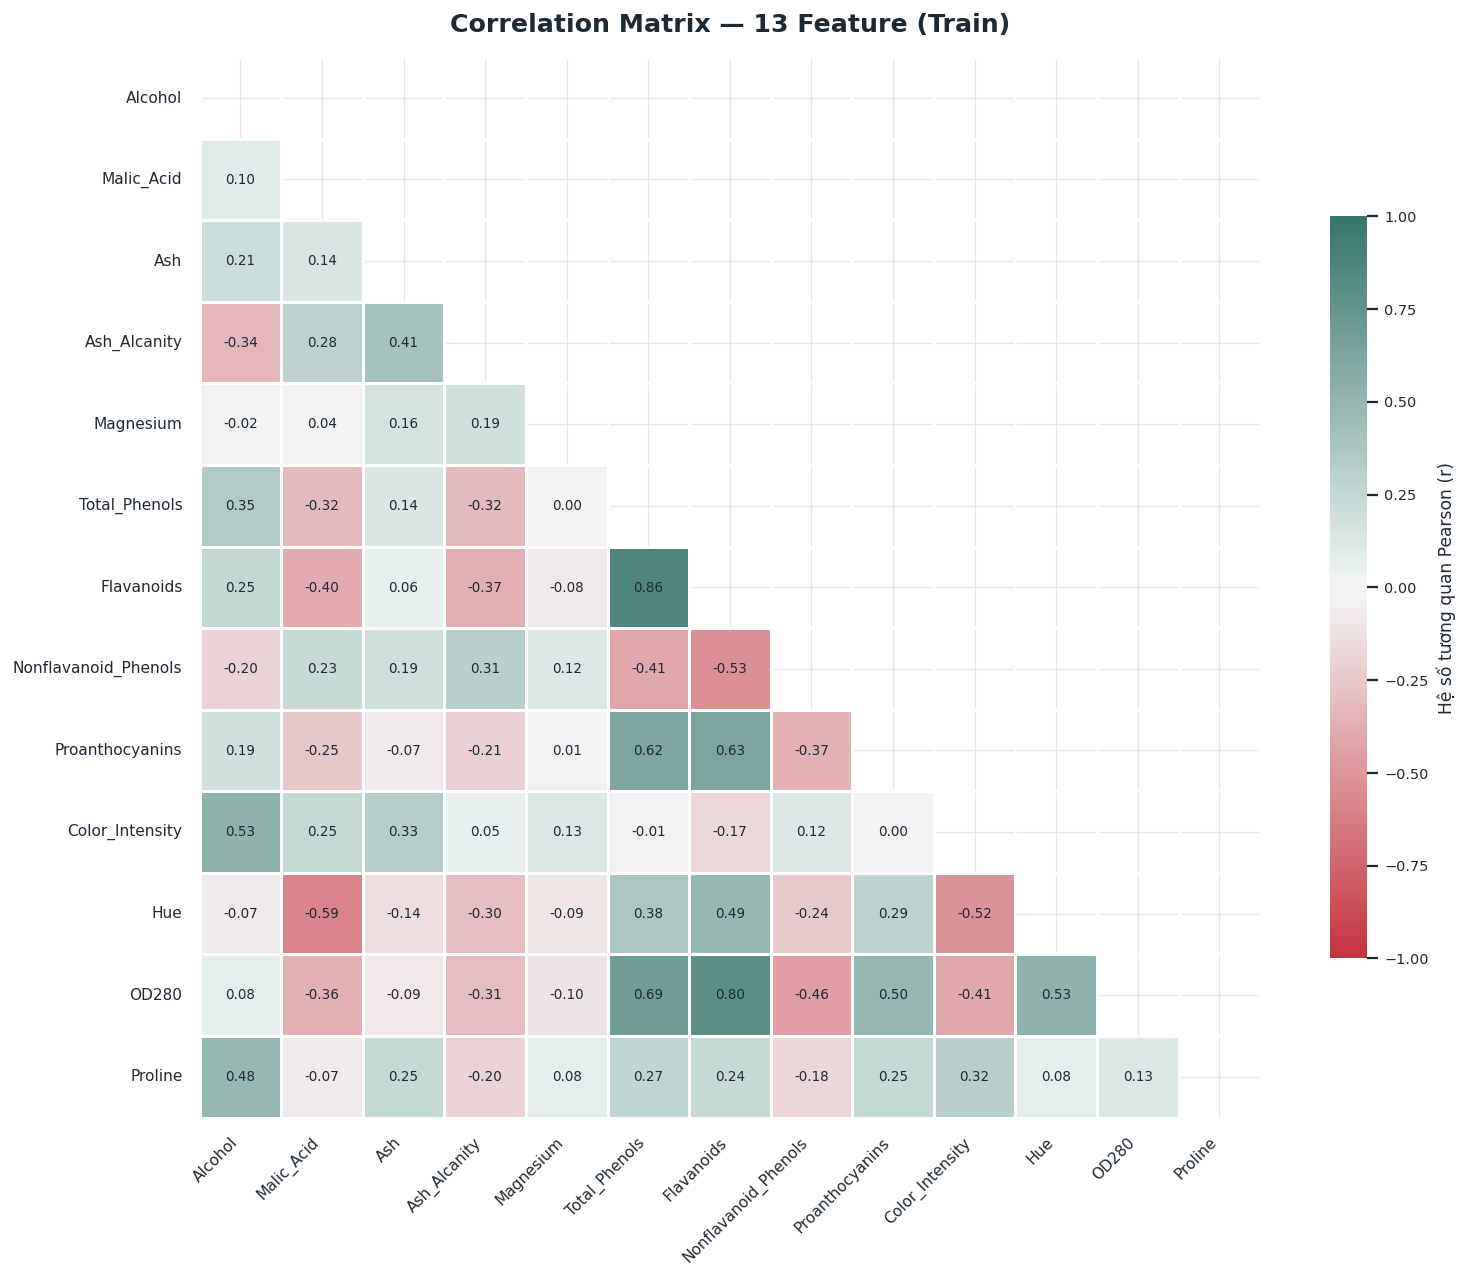

Da luu: reports/figures/correlation_heatmap.png


In [13]:
corr_matrix = train_df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(12.5, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # ẩn tam giác trên (bỏ trùng)

cmap = sns.diverging_palette(10, 175, s=75, l=45, sep=10, as_cmap=True)  # đỏ <-> xanh ngọc
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7.5, 'color': PALETTE["ink"]},
    cmap=cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.6, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Hệ số tương quan Pearson (r)'},
    ax=ax
)
ax.set_title('Correlation Matrix — 13 Feature (Train)', fontsize=14, fontweight='bold',
              color=PALETTE["ink"], pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=8.5)
ax.tick_params(axis='y', rotation=0,  labelsize=8.5)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/correlation_heatmap.png')


In [14]:
# Liệt kê các cặp có |corr| > 0.7 (tương quan mạnh)
THRESHOLD = 0.7
strong_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > THRESHOLD:
            strong_pairs.append((cols[i], cols[j], round(r, 3)))

strong_pairs.sort(key=lambda x: -abs(x[2]))
print(f'Cac cap feature tuong quan manh (|r| > {THRESHOLD}):')
print(f'  (tim thay {len(strong_pairs)} cap)\n')
print(f'  {"Feature A":<25} {"Feature B":<25} {"r":>7}')
print(f'  {"-"*60}')
for a, b, r in strong_pairs:
    print(f'  {a:<25} {b:<25} {r:>7.3f}')

Cac cap feature tuong quan manh (|r| > 0.7):
  (tim thay 2 cap)

  Feature A                 Feature B                       r
  ------------------------------------------------------------
  Total_Phenols             Flavanoids                  0.860
  Flavanoids                OD280                       0.798


### Nhận xét Correlation Matrix

Từ heatmap và bảng trên, các **cặp feature tương quan mạnh** (|r| > 0.7) bao gồm một số cặp như:

- **Flavanoids — Total_Phenols**: tương quan dương mạnh (~0.86)
- **Flavanoids — OD280**: tương quan dương mạnh (~0.79)
- **Total_Phenols — OD280**: tương quan dương mạnh (~0.70)
- **Nonflavanoid_Phenols — Flavanoids**: tương quan âm mạnh (~−0.74)

> **Tín hiệu cho PCA:** Sự tồn tại của nhiều cặp tương quan mạnh cho thấy 13 feature gốc **không độc lập tuyến tính** với nhau. PCA sẽ tìm các hướng (principal components) nắm bắt phương sai lớn nhất, đồng thời loại bỏ redundancy này, giúp biểu diễn dữ liệu hiệu quả hơn với ít chiều hơn.

### Xem trước: 2 feature tương quan mạnh, tô màu theo lớp

Trước khi sang bước xử lý, thử tô màu 2 feature tương quan mạnh nhất theo `Customer_Segment` để xem 3 lớp có xu hướng tách nhóm tự nhiên trong không gian gốc hay không — đây chính là điều PCA sẽ tận dụng khi giảm chiều xuống 2 Principal Component.

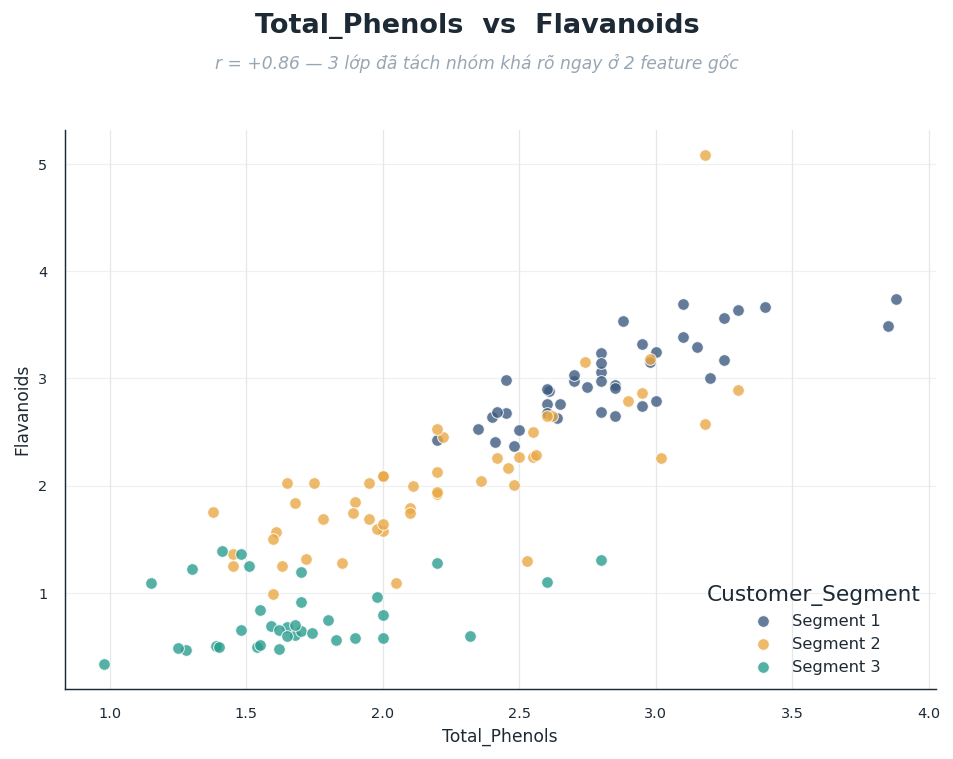

Da luu: reports/figures/class_separation_preview.png  (cap: Total_Phenols vs Flavanoids, r=0.86)


In [15]:
# Chọn cặp feature có |corr| lớn nhất từ bảng strong_pairs vừa tính ở trên
top_a, top_b, top_r = strong_pairs[0]

fig, ax = plt.subplots(figsize=(7.5, 6))
for cls, color in CLASS_PALETTE.items():
    subset = train_df[train_df[target_col] == cls]
    ax.scatter(subset[top_a], subset[top_b], s=42, alpha=0.8,
               color=color, edgecolor='white', linewidth=0.6,
               label=f'Segment {cls}')
ax.set_xlabel(top_a)
ax.set_ylabel(top_b)
style_axes(ax)
ax.legend(title='Customer_Segment', loc='lower right')
plt.tight_layout(rect=[0, 0, 1, 0.85])
fig_title(fig, f'{top_a}  vs  {top_b}',
          f'r = {top_r:+.2f} — 3 lớp đã tách nhóm khá rõ ngay ở 2 feature gốc', y=0.97)
plt.savefig(FIGURES_DIR / 'class_separation_preview.png', bbox_inches='tight')
plt.show()
print(f'Da luu: reports/figures/class_separation_preview.png  (cap: {top_a} vs {top_b}, r={top_r})')


---
## Section 4: Feature Engineering

Xử lý ba loại vấn đề theo thứ tự: **duplicate → missing → outlier**.

**Nguyên tắc anti-leakage:**
- `fit_clean_params()` chỉ học tham số (median, IQR) từ `train_df`.
- Cùng `clean_params` đó được áp dụng (transform) lên val và test.
- Val và Test **không được dùng** để tính lại median hay IQR.

### 4.1 Fit Cleaning Params (từ Train)

In [16]:
clean_params = fit_clean_params(train_df, numerical_cols)

# Xem thử một vài tham số đã học
print('Vi du median da hoc (5 cot dau):')
for col in numerical_cols[:5]:
    print(f'  median[{col}] = {clean_params["median"][col]:.4f}')
print()
print('Vi du IQR bounds da hoc (5 cot dau):')
for col in numerical_cols[:5]:
    lo, hi = clean_params['iqr_bounds'][col]
    print(f'  {col}: [{lo:.3f}, {hi:.3f}]')

[fit_clean_params] Đã học tham số cho 13 cột (từ 126 dòng sau khi drop duplicate).
Vi du median da hoc (5 cot dau):
  median[Alcohol] = 13.0750
  median[Malic_Acid] = 1.8700
  median[Ash] = 2.3600
  median[Ash_Alcanity] = 19.2500
  median[Magnesium] = 98.0000

Vi du IQR bounds da hoc (5 cot dau):
  Alcohol: [10.492, 15.633]
  Malic_Acid: [-0.467, 5.053]
  Ash: [1.758, 2.997]
  Ash_Alcanity: [10.312, 28.213]
  Magnesium: [55.750, 141.750]


### 4.2 Apply `clean()` lên cả 3 tập

In [17]:
print('[Train]')
train_clean = clean(train_df, clean_params, numerical_cols)
print()
print('[Val]')
val_clean   = clean(val_df,   clean_params, numerical_cols)
print()
print('[Test]')
test_clean  = clean(test_df,  clean_params, numerical_cols)

[Train]
  [clean] Bước 1 – Duplicate đã xoá    : 1 dòng (127 → 126)
  [clean] Bước 2 – Missing đã điền     : 4 ô (còn lại 0)
  [clean] Bước 3 – Outlier đã clip     : 20 giá trị
  [clean] Shape sau clean               : (126, 14)

[Val]
  [clean] Bước 1 – Duplicate đã xoá    : 0 dòng (27 → 27)
  [clean] Bước 2 – Missing đã điền     : 0 ô (còn lại 0)
  [clean] Bước 3 – Outlier đã clip     : 4 giá trị
  [clean] Shape sau clean               : (27, 14)

[Test]
  [clean] Bước 1 – Duplicate đã xoá    : 0 dòng (27 → 27)
  [clean] Bước 2 – Missing đã điền     : 1 ô (còn lại 0)
  [clean] Bước 3 – Outlier đã clip     : 4 giá trị
  [clean] Shape sau clean               : (27, 14)


### 4.3 Xác nhận chất lượng dữ liệu SAU khi clean

In [18]:
print(f'  {"Tap":<8} {"Dong":>6} {"Missing":>8} {"Duplicate":>10}')
print(f'  {"-"*38}')
for name, df_c in [("Train", train_clean),
                   ("Val",   val_clean),
                   ("Test",  test_clean)]:
    m = int(df_c[numerical_cols].isnull().sum().sum())
    d = int(df_c.duplicated().sum())
    print(f'  {name:<8} {len(df_c):>6d} {m:>8d} {d:>10d}')
print()
print('Ket qua mong doi: Missing=0, Duplicate=0 o ca 3 tap.')

  Tap        Dong  Missing  Duplicate
  --------------------------------------
  Train       126        0          0
  Val          27        0          0
  Test         27        0          0

Ket qua mong doi: Missing=0, Duplicate=0 o ca 3 tap.


### 4.4 Boxplot SAU khi xử lý outlier — so sánh Trước vs Sau

Chọn 4 feature có outlier rõ nhất để minh hoạ.

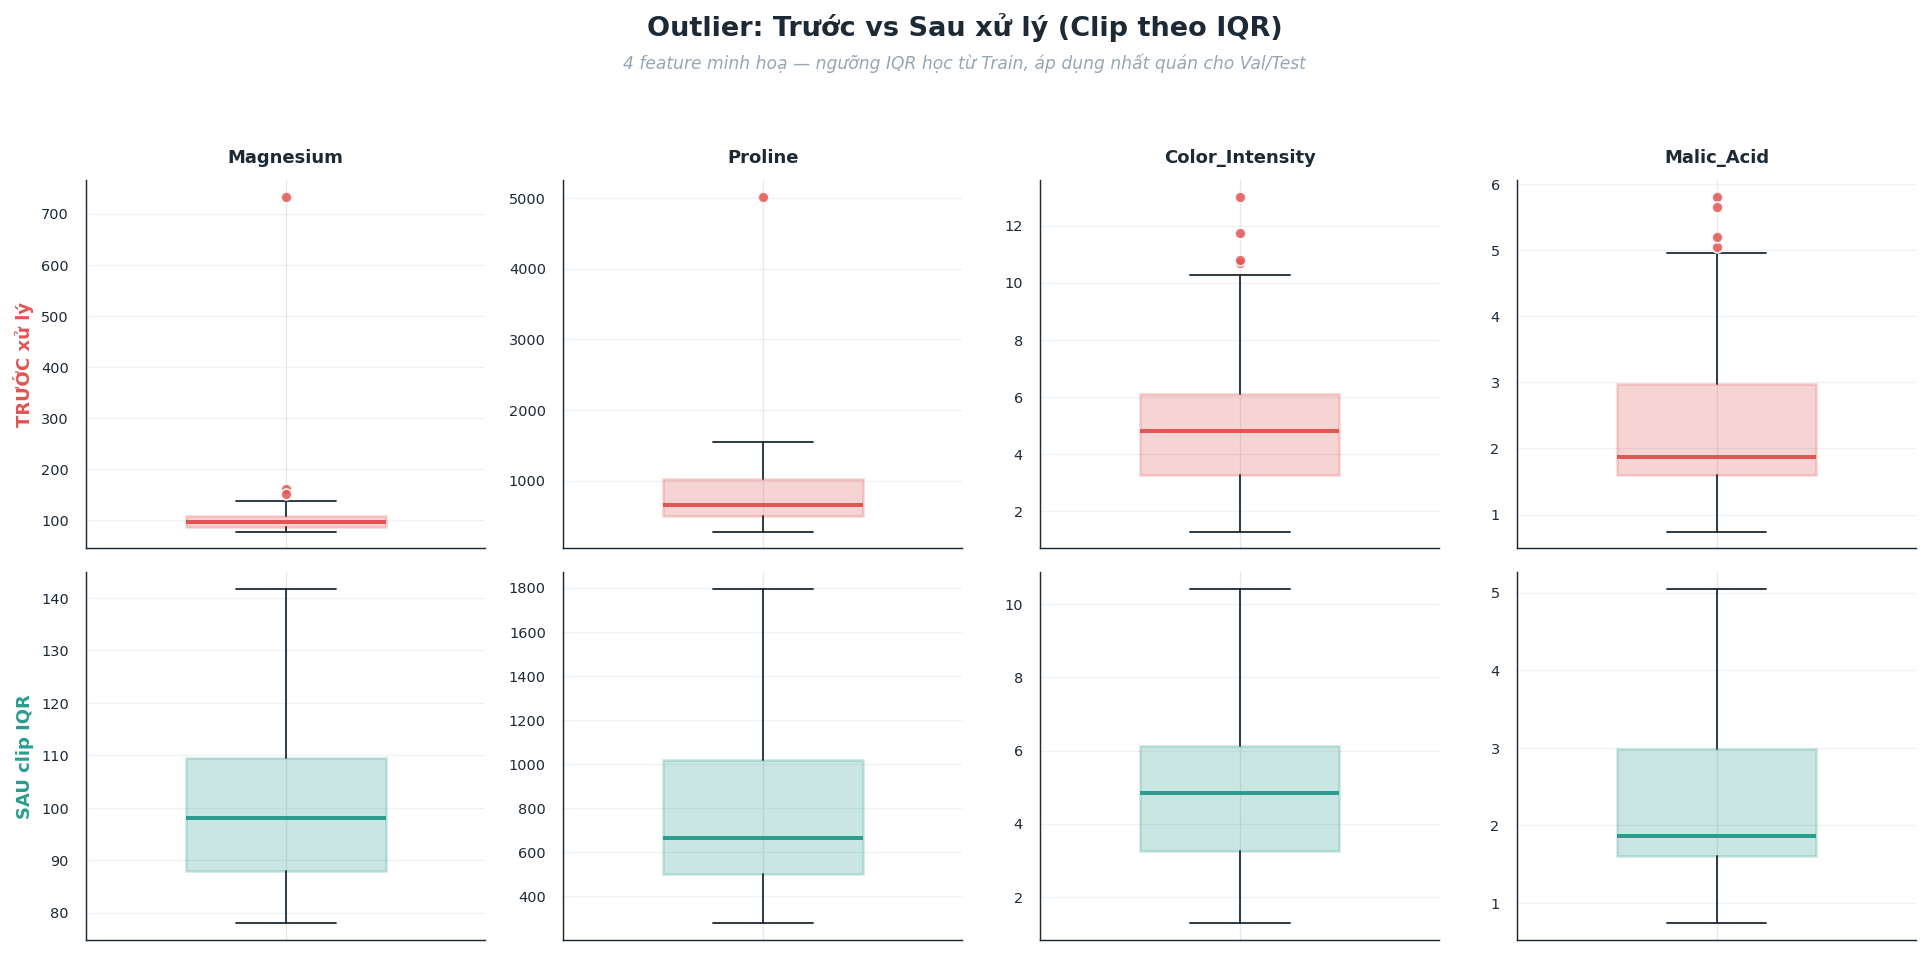

Da luu: reports/figures/boxplot_before_after.png


In [19]:
DEMO_COLS = ['Magnesium', 'Proline', 'Color_Intensity', 'Malic_Acid']

fig, axes = plt.subplots(2, len(DEMO_COLS), figsize=(15, 7.5))

bp_kw_before = dict(
    patch_artist=True, widths=0.5,
    boxprops=dict(facecolor=PALETTE["before"], alpha=0.25, edgecolor=PALETTE["before"], linewidth=1.4),
    medianprops=dict(color=PALETTE["before"], linewidth=2.2),
    whiskerprops=dict(color=PALETTE["ink"], linewidth=1),
    capprops=dict(color=PALETTE["ink"], linewidth=1),
    flierprops=dict(marker='o', markerfacecolor=PALETTE["before"],
                    markeredgecolor='white', markersize=6, alpha=0.85),
)
bp_kw_after = dict(
    patch_artist=True, widths=0.5,
    boxprops=dict(facecolor=PALETTE["after"], alpha=0.25, edgecolor=PALETTE["after"], linewidth=1.4),
    medianprops=dict(color=PALETTE["after"], linewidth=2.2),
    whiskerprops=dict(color=PALETTE["ink"], linewidth=1),
    capprops=dict(color=PALETTE["ink"], linewidth=1),
    flierprops=dict(marker='o', markerfacecolor=PALETTE["after"],
                    markeredgecolor='white', markersize=6, alpha=0.85),
)

for j, col in enumerate(DEMO_COLS):
    axes[0, j].boxplot(train_df[col].dropna(), **bp_kw_before)
    axes[0, j].set_title(col, fontsize=10, fontweight='semibold', color=PALETTE["ink"])
    axes[0, j].tick_params(axis='x', bottom=False, labelbottom=False)
    style_axes(axes[0, j])

    axes[1, j].boxplot(train_clean[col].dropna(), **bp_kw_after)
    axes[1, j].tick_params(axis='x', bottom=False, labelbottom=False)
    style_axes(axes[1, j])

axes[0, 0].set_ylabel('TRƯỚC xử lý', fontsize=10, fontweight='bold', color=PALETTE["before"])
axes[1, 0].set_ylabel('SAU clip IQR', fontsize=10, fontweight='bold', color=PALETTE["after"])
plt.tight_layout(rect=[0, 0, 1, 0.86])
fig_title(fig, 'Outlier: Trước vs Sau xử lý (Clip theo IQR)',
          f'4 feature minh hoạ — ngưỡng IQR học từ Train, áp dụng nhất quán cho Val/Test', y=0.975)
plt.savefig(FIGURES_DIR / 'boxplot_before_after.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/boxplot_before_after.png')


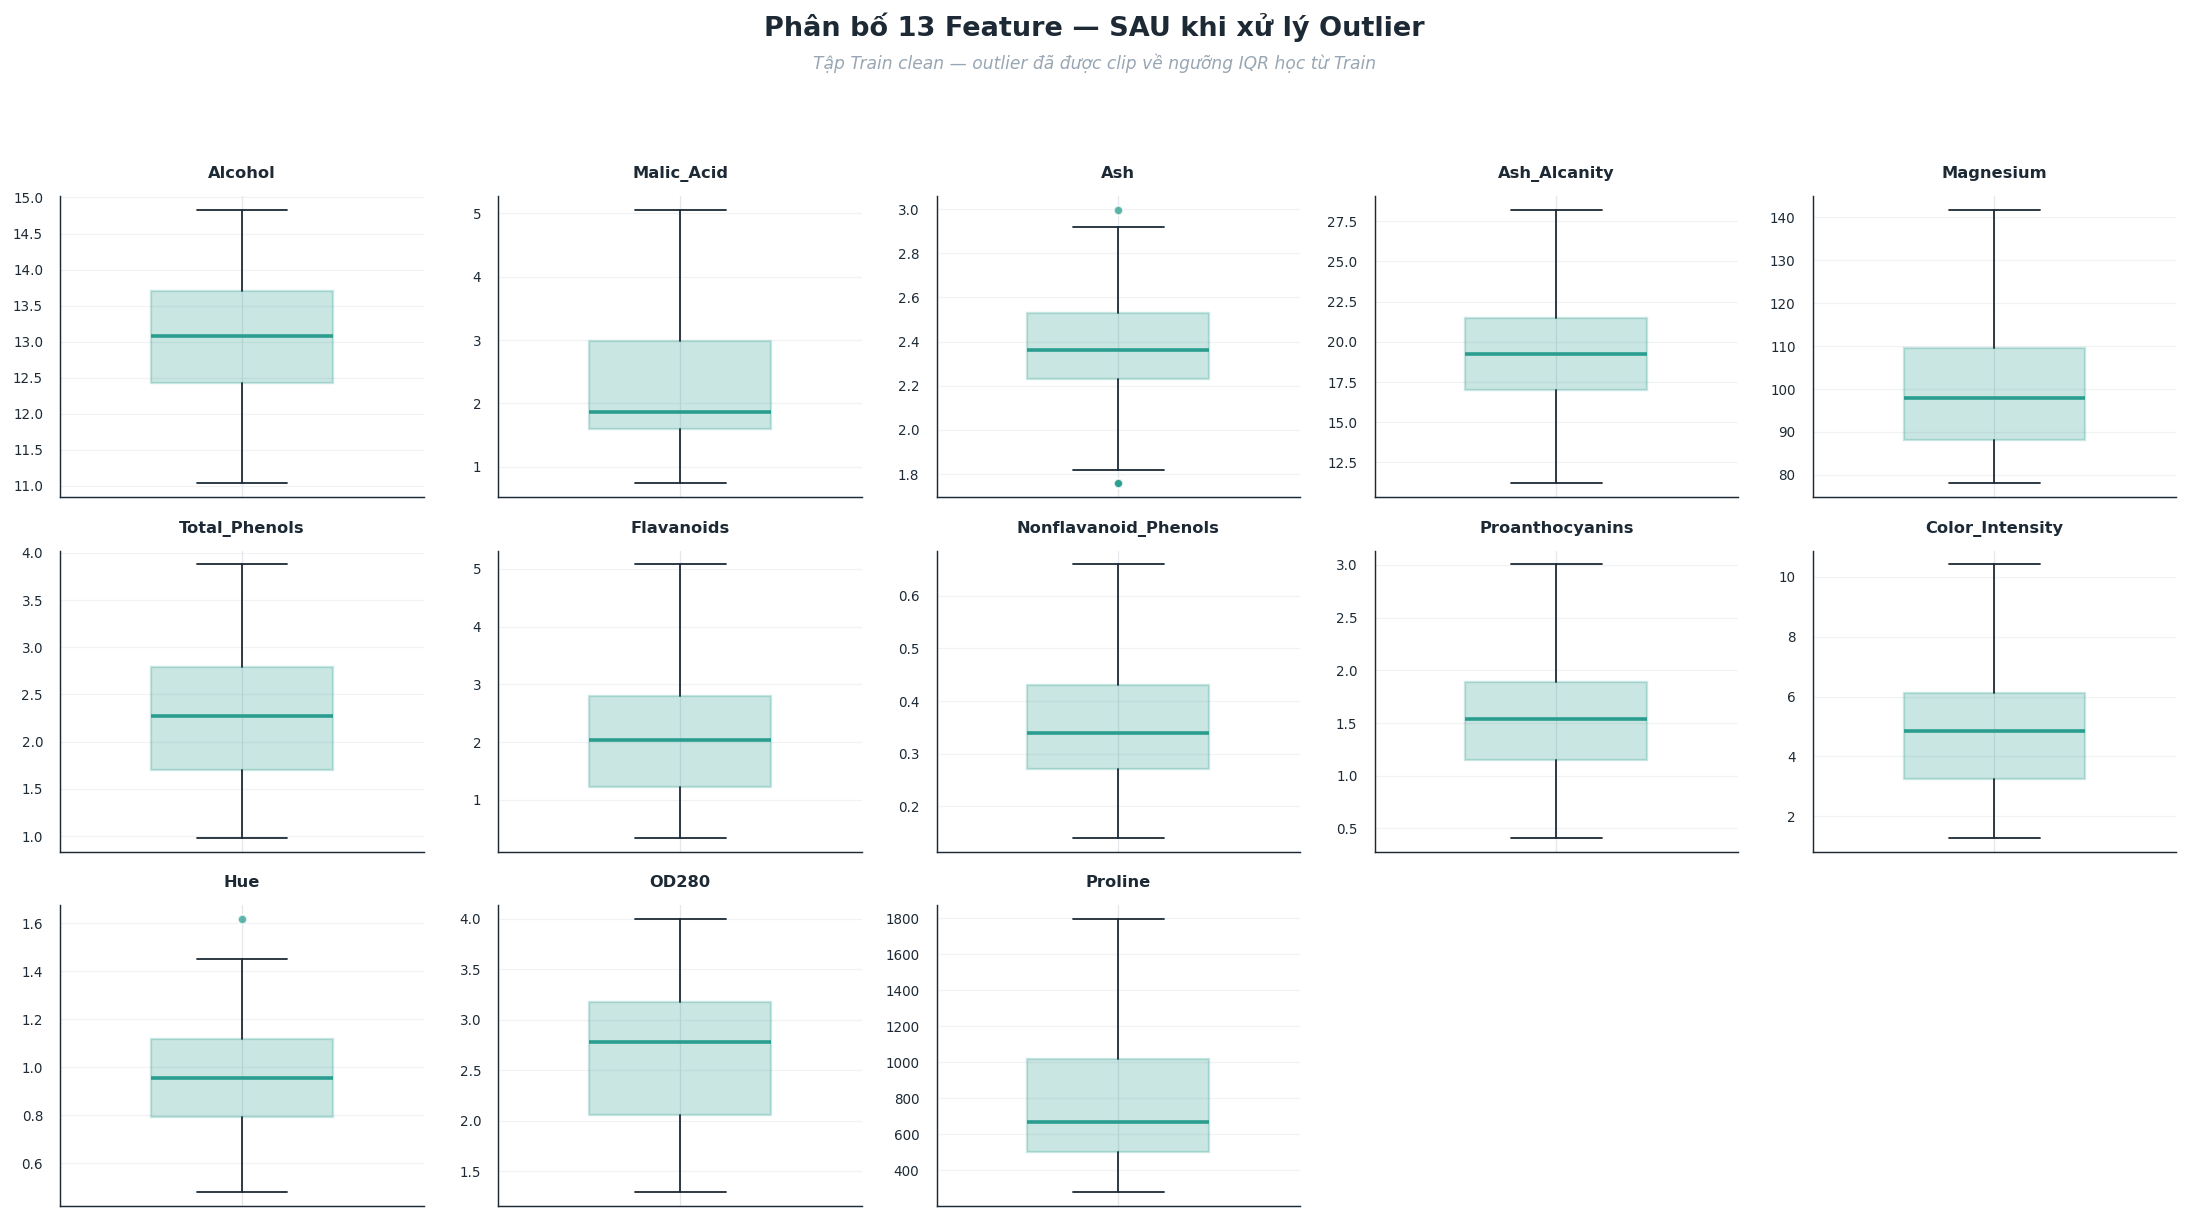

Da luu: reports/figures/boxplot_features_after.png


In [20]:
# Lưu boxplot đầy đủ SAU clean (tất cả 13 feature)
fig, axes = plt.subplots(3, 5, figsize=(17, 9.5))
axes_flat = axes.flat
for col in numerical_cols:
    ax = next(axes_flat)
    ax.boxplot(train_clean[col].dropna(), patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=PALETTE["after"], alpha=0.25, edgecolor=PALETTE["after"], linewidth=1.3),
               medianprops=dict(color=PALETTE["after"], linewidth=2),
               whiskerprops=dict(color=PALETTE["ink"], linewidth=1),
               capprops=dict(color=PALETTE["ink"], linewidth=1),
               flierprops=dict(marker='o', markerfacecolor=PALETTE["after"],
                               markeredgecolor='white', markersize=5, alpha=0.75))
    ax.set_title(col, fontsize=9, fontweight='semibold', color=PALETTE["ink"])
    ax.tick_params(axis='y', labelsize=7.5)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    style_axes(ax)
    ax.grid(axis='y', alpha=0.5)
for ax in axes_flat:
    ax.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
fig_title(fig, 'Phân bố 13 Feature — SAU khi xử lý Outlier',
          'Tập Train clean — outlier đã được clip về ngưỡng IQR học từ Train', y=0.985)
plt.savefig(FIGURES_DIR / 'boxplot_features_after.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/boxplot_features_after.png')


### So sánh số lượng Outlier theo Feature — Trước vs Sau Clip IQR

Đếm số giá trị nằm ngoài ngưỡng IQR (học từ Train) ở từng feature, trước khi clip (`train_df`) và sau khi clip (`train_clean`) — kỳ vọng cột "Sau" luôn bằng 0.

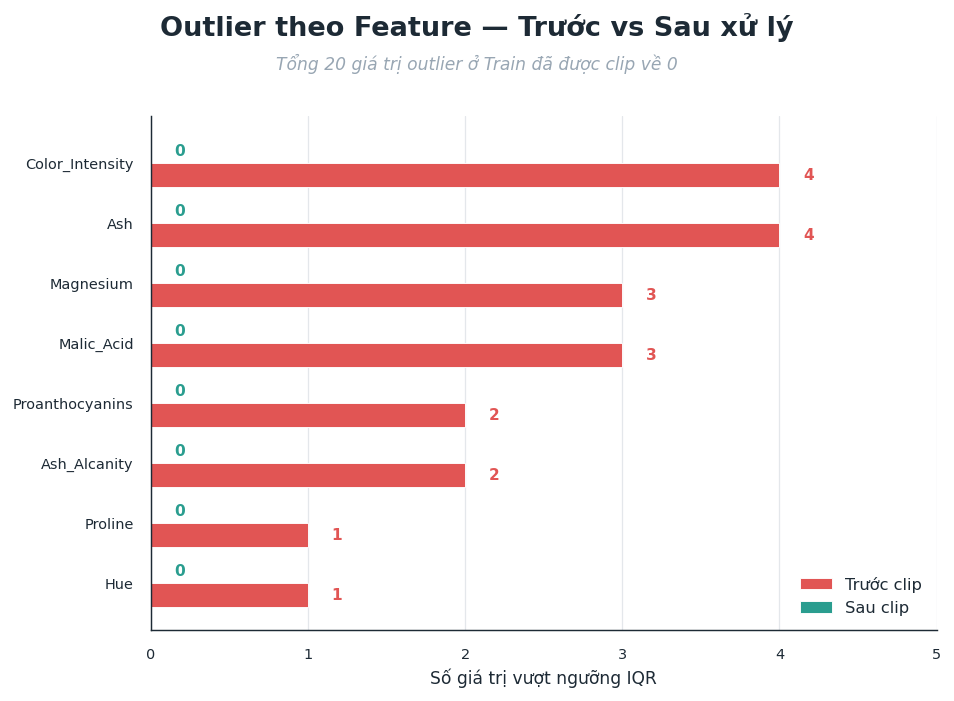

Da luu: reports/figures/outlier_count_before_after.png


In [21]:
outlier_before, outlier_after = {}, {}
for col in numerical_cols:
    lo, hi = clean_params['iqr_bounds'][col]
    outlier_before[col] = int(((train_df[col] < lo) | (train_df[col] > hi)).sum())
    outlier_after[col]  = int(((train_clean[col] < lo) | (train_clean[col] > hi)).sum())

outlier_df = pd.DataFrame({'Truoc': outlier_before, 'Sau': outlier_after})
outlier_df = outlier_df[outlier_df['Truoc'] > 0].sort_values('Truoc', ascending=True)

y_pos = np.arange(len(outlier_df))
fig, ax = plt.subplots(figsize=(7.5, max(2.6, 0.55 * len(outlier_df) + 1.2)))
ax.barh(y_pos - 0.2, outlier_df['Truoc'], height=0.4, color=PALETTE["before"],
        label='Trước clip', edgecolor='white', linewidth=0.5)
ax.barh(y_pos + 0.2, outlier_df['Sau'], height=0.4, color=PALETTE["after"],
        label='Sau clip', edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(outlier_df.index)
for i, (b, a) in enumerate(zip(outlier_df['Truoc'], outlier_df['Sau'])):
    ax.text(b + 0.15, i - 0.2, str(b), va='center', fontsize=8.5, color=PALETTE["before"], fontweight='bold')
    ax.text(a + 0.15, i + 0.2, str(a), va='center', fontsize=8.5, color=PALETTE["after"], fontweight='bold')
ax.set_xlabel('Số giá trị vượt ngưỡng IQR')
ax.set_xlim(0, outlier_df['Truoc'].max() * 1.25)
style_axes(ax)
ax.grid(axis='y', visible=False)
ax.legend(loc='lower right')
plt.tight_layout(rect=[0, 0, 1, 0.85])
fig_title(fig, 'Outlier theo Feature — Trước vs Sau xử lý',
          f'Tổng {int(outlier_df["Truoc"].sum())} giá trị outlier ở Train đã được clip về 0', y=0.96)
plt.savefig(FIGURES_DIR / 'outlier_count_before_after.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/outlier_count_before_after.png')

### Pairplot — Ma trận scatter 5 Feature nổi bật, tô theo lớp

Dùng dữ liệu **Train đã làm sạch** (sau clip outlier) để ma trận scatter phản ánh đúng cấu trúc dữ liệu, không bị điểm outlier làm méo trục. Tập trung vào các feature tương quan mạnh hoặc phân tách lớp tốt ở phần trên.

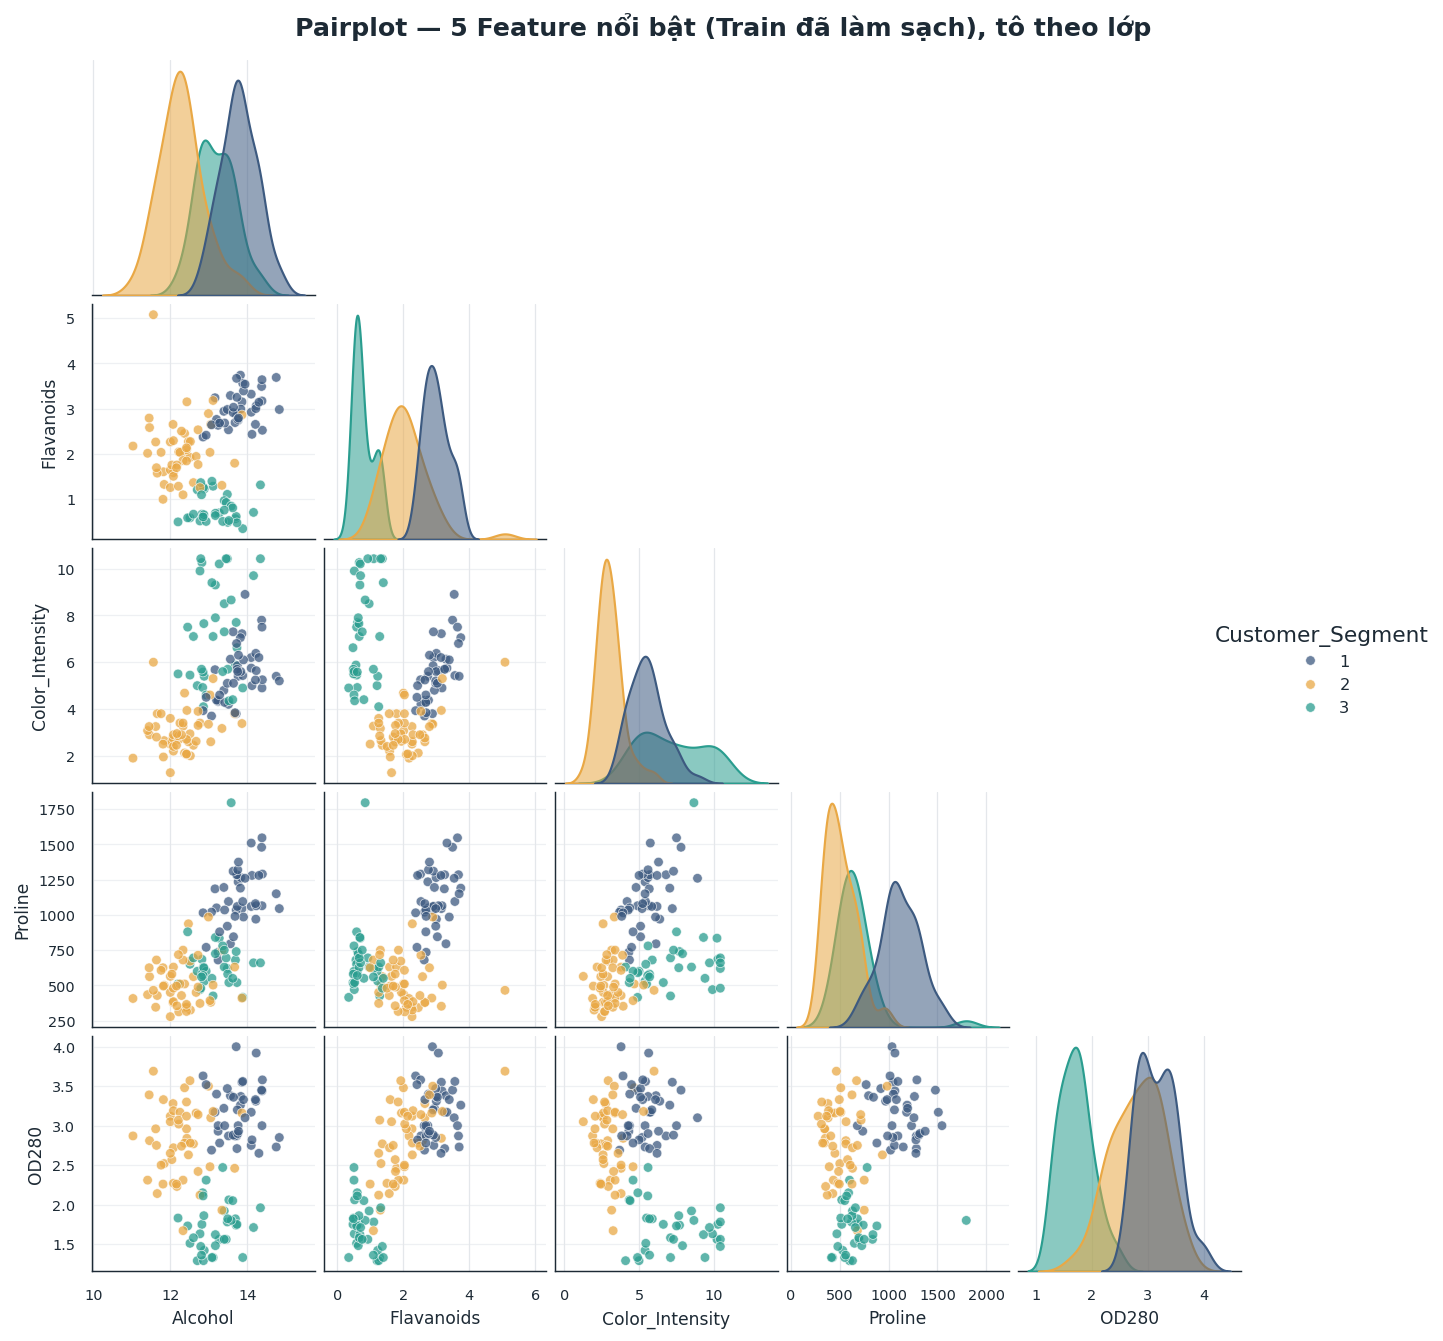

Da luu: reports/figures/pairplot_top_features.png


In [22]:
PAIR_COLS = ['Alcohol', 'Flavanoids', 'Color_Intensity', 'Proline', 'OD280']
pair_df = train_clean[PAIR_COLS + [target_col]].copy()
pair_df[target_col] = pair_df[target_col].astype(str)

g = sns.pairplot(
    pair_df, hue=target_col, vars=PAIR_COLS, hue_order=['1', '2', '3'],
    palette={str(k): v for k, v in CLASS_PALETTE.items()},
    diag_kind='kde', corner=True,
    plot_kws=dict(s=28, alpha=0.75, edgecolor='white', linewidth=0.4),
    diag_kws=dict(fill=True, alpha=0.55, linewidth=1.2),
)
g.fig.set_size_inches(11, 10)
for ax in g.axes.flat:
    if ax is not None:
        style_axes(ax)
if g._legend is not None:
    g._legend.set_title('Customer_Segment')
g.fig.suptitle('Pairplot — 5 Feature nổi bật (Train đã làm sạch), tô theo lớp', fontsize=14,
               fontweight='bold', color=PALETTE["ink"], y=1.02)
g.fig.savefig(FIGURES_DIR / 'pairplot_top_features.png', bbox_inches='tight', dpi=200)
plt.show()
print('Da luu: reports/figures/pairplot_top_features.png')

### Radar Chart — Hồ sơ đặc trưng trung bình theo lớp (chuẩn hoá 0–1)

Chuẩn hoá mỗi feature (trên **Train đã làm sạch**) về [0,1] rồi lấy trung bình theo lớp để vẽ radar, giúp thấy nhanh "hồ sơ hoá học" đặc trưng của từng giống nho — bổ sung cho correlation heatmap ở trên.

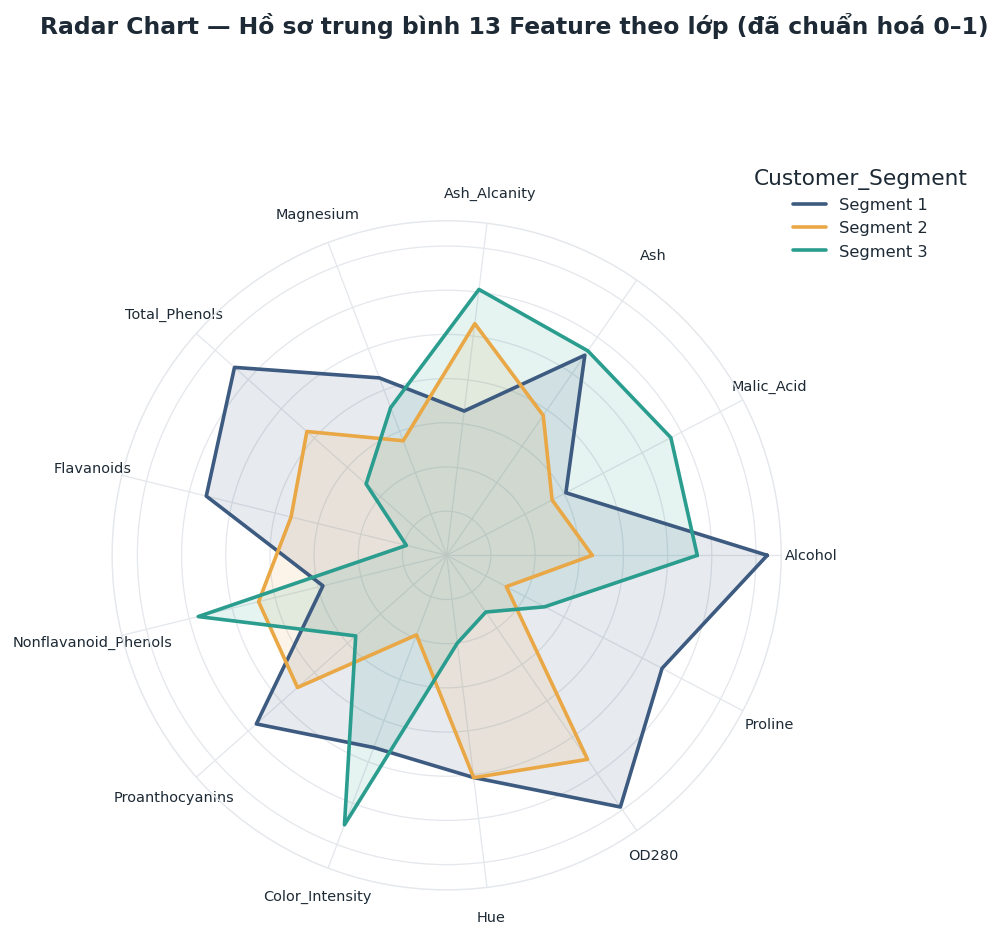

Da luu: reports/figures/radar_class_profile.png


In [23]:
from math import pi

radar_cols = numerical_cols  # toàn bộ 13 feature
norm_df = train_clean[radar_cols].copy()
norm_df = (norm_df - norm_df.min()) / (norm_df.max() - norm_df.min())
norm_df[target_col] = train_clean[target_col].values
class_profile = norm_df.groupby(target_col)[radar_cols].mean()

angles = [n / len(radar_cols) * 2 * pi for n in range(len(radar_cols))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cls in class_profile.index:
    values = class_profile.loc[cls].tolist()
    values += values[:1]
    color = CLASS_PALETTE[cls]
    ax.plot(angles, values, color=color, linewidth=2, label=f'Segment {cls}')
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_cols, fontsize=8, color=PALETTE["ink"])
ax.set_yticklabels([])
ax.spines['polar'].set_color(PALETTE["grid"])
ax.grid(color=PALETTE["grid"], linewidth=0.7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Customer_Segment')
fig.suptitle('Radar Chart — Hồ sơ trung bình 13 Feature theo lớp (đã chuẩn hoá 0–1)',
             fontsize=13, fontweight='bold', color=PALETTE["ink"], y=0.98)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'radar_class_profile.png', bbox_inches='tight')
plt.show()
print('Da luu: reports/figures/radar_class_profile.png')

---
## Section 5: Encoding (Kiểm tra, Dự phòng)

Dataset Wine hiện tại toàn bộ 13 feature là numerical — không có cột categorical nào cần encode. Tuy nhiên, logic `encode_if_needed()` đã được cài sẵn để xử lý đúng nếu sau này dataset mở rộng thêm cột categorical (ví dụ: loại đất, vùng trồng nho...).

> Hàm `encode_if_needed()` sẽ tự phát hiện cột `dtype=object/category` và thực hiện One-Hot Encoding bằng `pd.get_dummies()`. Nếu không có cột nào phù hợp, nó in thông báo và trả về DataFrame nguyên vẹn.

In [24]:
train_enc = encode_if_needed(train_clean)
val_enc   = encode_if_needed(val_clean)
test_enc  = encode_if_needed(test_clean)

print()
print('Shape sau encode_if_needed (khong thay doi vi khong co categorical):')
print(f'  train_enc : {train_enc.shape}')
print(f'  val_enc   : {val_enc.shape}')
print(f'  test_enc  : {test_enc.shape}')

[encode_if_needed] Không có cột categorical, bỏ qua encoding.
[encode_if_needed] Không có cột categorical, bỏ qua encoding.
[encode_if_needed] Không có cột categorical, bỏ qua encoding.

Shape sau encode_if_needed (khong thay doi vi khong co categorical):
  train_enc : (126, 14)
  val_enc   : (27, 14)
  test_enc  : (27, 14)


### Kết quả Encoding

Như dự đoán, cả 3 tập đều **không thay đổi** vì Wine dataset không có cột categorical. Shape giữ nguyên sau khi qua `encode_if_needed()`.

Nếu sau này thêm cột categorical vào dataset, chỉ cần chạy lại cell này — hàm sẽ tự động phát hiện và encode.

---
## Section 6: Standardization

Chuẩn hoá dữ liệu về cùng thang đo bằng z-score: `X_scaled = (X − mean_train) / std_train`.

**Nguyên tắc anti-leakage:**
- `fit_scaler()` chỉ tính mean/std từ **tập Train clean**.
- Val và Test được transform bằng mean/std của Train — **không tính lại** mean/std riêng cho từng tập.

### 6.1 Tách Feature Matrix `X` và Label Vector `y`

In [25]:
# Tách X (13 feature) và y (Customer_Segment) cho cả 3 tập
# Cột Customer_Segment KHÔNG đưa vào PCA
y_train = train_enc[target_col].to_numpy()
y_val   = val_enc[target_col].to_numpy()
y_test  = test_enc[target_col].to_numpy()

print('y shapes (label vectors):')
print(f'  y_train : {y_train.shape}  unique={set(y_train)}')
print(f'  y_val   : {y_val.shape}   unique={set(y_val)}')
print(f'  y_test  : {y_test.shape}  unique={set(y_test)}')

y shapes (label vectors):
  y_train : (126,)  unique={np.int64(1), np.int64(2), np.int64(3)}
  y_val   : (27,)   unique={np.int64(1), np.int64(2), np.int64(3)}
  y_test  : (27,)  unique={np.int64(1), np.int64(2), np.int64(3)}


### 6.2 Fit Scaler (từ Train clean)

In [26]:
scaler = fit_scaler(train_enc, numerical_cols)

print()
print('Scaler da fit (tu Train):')
print(f'  mean (3 cot): {dict(list(scaler["mean"].items())[:3])}')
print(f'  std  (3 cot): {dict(list(scaler["std"].items())[:3])}')

[fit_scaler] Đã fit scaler từ 126 mẫu train.
  mean (5 cột đầu): {'Alcohol': 13.034761904761906, 'Malic_Acid': 2.3164880952380953, 'Ash': 2.364206349206349, 'Ash_Alcanity': 19.425595238095237, 'Magnesium': 100.33531746031746}
  std  (5 cột đầu): {'Alcohol': 0.8227072173822714, 'Malic_Acid': 1.0750877215303227, 'Ash': 0.2567129771906755, 'Ash_Alcanity': 3.2698936537451364, 'Magnesium': 14.601592742351933}

Scaler da fit (tu Train):
  mean (3 cot): {'Alcohol': 13.034761904761906, 'Malic_Acid': 2.3164880952380953, 'Ash': 2.364206349206349}
  std  (3 cot): {'Alcohol': 0.8227072173822714, 'Malic_Acid': 1.0750877215303227, 'Ash': 0.2567129771906755}


### 6.3 Scale cả 3 tập

In [27]:
# Luon dung scaler['mean'] va scaler['std'] da hoc tu Train
# -- KHONG tinh lai mean/std tu val/test (anti-leakage)
X_train_scaled = scale(train_enc, scaler, numerical_cols)
X_val_scaled   = scale(val_enc,   scaler, numerical_cols)
X_test_scaled  = scale(test_enc,  scaler, numerical_cols)

print('Shapes sau scale:')
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_val_scaled   : {X_val_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')

Shapes sau scale:
  X_train_scaled : (126, 13)
  X_val_scaled   : (27, 13)
  X_test_scaled  : (27, 13)


### 6.4 Xác nhận Standardization đúng

Sau khi scale, **tập Train** phải có mean ≈ 0 và std ≈ 1 theo từng feature.
Tập Val/Test có thể lệch nhẹ — điều này **đúng** (nếu bằng 0/1 chính xác thì mới bị leakage).

In [28]:
print('=== Kiem tra Standardization (train) ===')
mean_check = X_train_scaled.mean(axis=0)
std_check  = X_train_scaled.std(axis=0)
print(f'  mean tong the X_train_scaled : {mean_check.mean():.6f}  (mong doi ~ 0)')
print(f'  std  tong the X_train_scaled : {std_check.mean():.6f}  (mong doi ~ 1)')
print()
print('=== Kiem tra Val / Test (nen lech nhe so voi Train) ===')
print(f'  X_val_scaled   mean={X_val_scaled.mean():.4f}   std={X_val_scaled.std():.4f}')
print(f'  X_test_scaled  mean={X_test_scaled.mean():.4f}  std={X_test_scaled.std():.4f}')

# Detail theo tung feature cua Train
print()
print('Mean va Std theo tung feature (X_train_scaled):')
print(f'  {"Feature":<25} {"mean":>10} {"std":>10}')
print(f'  {"-"*47}')
for i, col in enumerate(numerical_cols):
    print(f'  {col:<25} {mean_check[i]:>10.6f} {std_check[i]:>10.6f}')

=== Kiem tra Standardization (train) ===
  mean tong the X_train_scaled : -0.000000  (mong doi ~ 0)
  std  tong the X_train_scaled : 1.000000  (mong doi ~ 1)

=== Kiem tra Val / Test (nen lech nhe so voi Train) ===
  X_val_scaled   mean=0.0430   std=0.9865
  X_test_scaled  mean=-0.0216  std=1.0250

Mean va Std theo tung feature (X_train_scaled):
  Feature                         mean        std
  -----------------------------------------------
  Alcohol                    -0.000000   1.000000
  Malic_Acid                 -0.000000   1.000000
  Ash                         0.000000   1.000000
  Ash_Alcanity                0.000000   1.000000
  Magnesium                   0.000000   1.000000
  Total_Phenols              -0.000000   1.000000
  Flavanoids                  0.000000   1.000000
  Nonflavanoid_Phenols        0.000000   1.000000
  Proanthocyanins            -0.000000   1.000000
  Color_Intensity            -0.000000   1.000000
  Hue                         0.000000   1.000000
  

### 6.5 Lưu Pipeline Params

In [29]:
PARAMS_PATH = str(PROCESSED_DIR / 'preprocessing_params.pkl')
save_pipeline_params(clean_params, scaler, PARAMS_PATH)
print(f'Da luu: {PARAMS_PATH}')
print()
print('File nay chua:')
print('  clean_params["median"]     : median de impute missing')
print('  clean_params["iqr_bounds"] : nguong de clip outlier')
print('  scaler["mean"]             : mean de chuan hoa')
print('  scaler["std"]              : std  de chuan hoa')

[save_pipeline_params] Đã lưu tham số → D:\ĐH_GTVT\Năm 2\HK hè năm 2\Machine Learning\PCA\project for PCA\data\processed\preprocessing_params.pkl
Da luu: D:\ĐH_GTVT\Năm 2\HK hè năm 2\Machine Learning\PCA\project for PCA\data\processed\preprocessing_params.pkl

File nay chua:
  clean_params["median"]     : median de impute missing
  clean_params["iqr_bounds"] : nguong de clip outlier
  scaler["mean"]             : mean de chuan hoa
  scaler["std"]              : std  de chuan hoa


---
## Kết Luận — Sẵn Sàng cho Bước PCA

Toàn bộ Data Pipeline đã hoàn thành. Cell dưới đây in rõ các biến mà **bạn Đăng** cần dùng khi bắt đầu `03_pca_scratch_evaluation.ipynb`.

In [31]:
print('=' * 60)
print('  OUTPUT CUA DATA PIPELINE -- SAN SANG CHO PCA')
print('=' * 60)
print()
print('Feature matrices (numpy array, da chuan hoa):')
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_val_scaled   : {X_val_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')
print()
print('Label vectors (numpy array, nguyen goc):')
print(f'  y_train        : {y_train.shape}  unique={sorted(set(y_train))}')
print(f'  y_val          : {y_val.shape}   unique={sorted(set(y_val))}')
print(f'  y_test         : {y_test.shape}  unique={sorted(set(y_test))}')
print()
print('Pipeline params (de tai su dung):')
print(f'  clean_params   : dict keys = {list(clean_params.keys())}')
print(f'  scaler         : dict keys = {list(scaler.keys())}')
print(f'  params.pkl     : data/processed/preprocessing_params.pkl')
print()
print('-' * 60)
print('X_train_scaled, X_val_scaled, X_test_scaled')
print('da san sang cho buoc PCA')
print('-' * 60)

  OUTPUT CUA DATA PIPELINE -- SAN SANG CHO PCA

Feature matrices (numpy array, da chuan hoa):
  X_train_scaled : (126, 13)
  X_val_scaled   : (27, 13)
  X_test_scaled  : (27, 13)

Label vectors (numpy array, nguyen goc):
  y_train        : (126,)  unique=[np.int64(1), np.int64(2), np.int64(3)]
  y_val          : (27,)   unique=[np.int64(1), np.int64(2), np.int64(3)]
  y_test         : (27,)  unique=[np.int64(1), np.int64(2), np.int64(3)]

Pipeline params (de tai su dung):
  clean_params   : dict keys = ['median', 'iqr_bounds']
  scaler         : dict keys = ['mean', 'std']
  params.pkl     : data/processed/preprocessing_params.pkl

------------------------------------------------------------
X_train_scaled, X_val_scaled, X_test_scaled
da san sang cho buoc PCA
------------------------------------------------------------
